[Home](../../README.md)

### Data Preprocessing

This Jupyter Notebook demonstrates different processes you can apply to your data to better understand it before data wrangling. For this demonstration we will use relatively a complex real dataset that compares health measures with the speed of progress of type 2 adult onset diabetes.

#### Load the required dependencies

Load the two required dependencies:

- [Numpy](https://numpy.org/doc/stable/) is a library that enables numerical computing with Python
- [Pandas](https://pandas.pydata.org/) is library for data analysis and manipulation.
- [Matplotlib](https://matplotlib.org) a comprehensive library for creating static, animated, and interactive visualizations in Python. A customised stylesheet for the visualisations is also applied.

In [4]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [5]:
data_frame = pd.read_csv("2.1.2.domain_properties.csv")

#### Data Snapshot

It is important to get a high-level look at your dataset to understand what you are working with. Printing the complete data might be impossible for large-scale datasets where the rows can be in thousands or even millions.

You can use the `head()` and `tail()` method call to inspect the first and last 5 rows of your dataset.

In [6]:
# Target = A measure of disease progression in one year
data_frame.head()

,price,date_sold,suburb,num_bath,num_bed,num_parking,property_size,type,suburb_population,suburb_median_income,suburb_sqkm,suburb_lat,suburb_lng,suburb_elevation,cash_rate,property_inflation_index,km_from_cbd
0,530000,13/1/16,Kincumber,4,4,2,1351,House,7093,29432,9.914,-33.47252,151.40208,24,2.0,150.9,47.05
1,525000,13/1/16,Halekulani,2,4,2,594,House,2538,24752,1.397,-33.21772,151.55237,23,2.0,150.9,78.54
2,480000,13/1/16,Chittaway Bay,2,4,2,468,House,2028,31668,1.116,-33.32678,151.44557,3,2.0,150.9,63.59
3,452000,13/1/16,Leumeah,1,3,1,344,House,9835,32292,4.055,-34.05375,150.83957,81,2.0,150.9,40.12
4,365500,13/1/16,North Avoca,0,0,0,1850,Vacant land,2200,45084,1.497,-33.45608,151.43598,18,2.0,150.9,49.98


####  Data Summary
 
The `info()` method call prints a summary of each column, giving you more information about the specific data types, total number of rows, null values and memory usage.

In [7]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 11160 entries, 0 to 11159
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     11160 non-null  int64  
 1   date_sold                 11160 non-null  str    
 2   suburb                    11160 non-null  str    
 3   num_bath                  11160 non-null  int64  
 4   num_bed                   11160 non-null  int64  
 5   num_parking               11160 non-null  int64  
 6   property_size             11160 non-null  int64  
 7   type                      11160 non-null  str    
 8   suburb_population         11160 non-null  int64  
 9   suburb_median_income      11160 non-null  int64  
 10  suburb_sqkm               11160 non-null  float64
 11  suburb_lat                11160 non-null  float64
 12  suburb_lng                11160 non-null  float64
 13  suburb_elevation          11160 non-null  int64  
 14  cash_rate        

#### Statistics For Numerical Columns
 
The `describe()` method call provides basic statistical knowledge like the mean and spread of the data.

In [8]:
data_frame.describe()

,price,num_bath,num_bed,num_parking,property_size,suburb_population,suburb_median_income,suburb_sqkm,suburb_lat,suburb_lng,suburb_elevation,cash_rate,property_inflation_index,km_from_cbd
count,1.116000e+04,11160.000000,11160.000000,11160.000000,11160.000000,11160.000000,11160.000000,11160.000000,11160.000000,11160.000000,11160.000000,11160.000000,11160.000000,11160.000000
mean,1.675395e+06,2.073566,3.758961,2.017473,723.012366,9311.560036,40168.243369,5.054877,-33.781413,151.096676,55.606720,0.631361,188.489686,27.381826
std,1.290371e+06,1.184881,1.559743,1.454560,1048.983662,7541.636246,11089.955120,5.824663,0.202478,0.213456,52.802315,0.658624,24.441552,18.470113
min,2.250000e+05,0.000000,0.000000,0.000000,7.000000,22.000000,14248.000000,0.089000,-34.106240,150.553840,0.000000,0.100000,150.900000,0.310000
25%,1.002000e+06,1.000000,3.000000,1.000000,430.000000,3977.000000,32448.000000,1.776000,-33.921480,150.951020,21.000000,0.100000,167.600000,12.960000
50%,1.388000e+06,2.000000,4.000000,2.000000,600.000000,7457.000000,39104.000000,3.566000,-33.809180,151.109470,40.000000,0.110000,176.600000,22.310000
75%,2.020000e+06,3.000000,4.000000,2.000000,765.000000,12158.250000,45552.000000,6.568000,-33.715510,151.227810,75.000000,1.500000,220.100000,40.990000
max,6.000000e+07,46.000000,47.000000,50.000000,59100.000000,47176.000000,97500.000000,87.154000,-33.163760,151.573300,405.000000,2.000000,220.100000,84.790000


#### The data columns are:

| Column | Data |
| ------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Price         | The price the property was sold at.  |
| Date Sold     | The date the property was sold recorded as D/MM/YYYY. |
| Suburb        | The suburb the property is situated in. |
| No. Bath      | Count of how many bathrooms the property has. |
| No. Bed       | Count of how many bedrooms the property has. |
| No. Parking   | Count of how many parking spaces the property has. |
| Property Size | The size of the property measured in squared meters. |
| Type          | The type of building e.g. House, Apartment, Vacant land. |
| Suburb Pop.   | The population of the suburb the property is situated in. |
| SMI           | (Suburb Median Income) The median income of the suburb the property is situated in. |
| Suburb SQKM   | The median income of the suburb the property is situated in. |
| Suburb Lat    | The latitude of the suburb that the property is situated in. |
| Suburb Lng    | The longitude of the suburb that the property is situated in. |
| Suburb Elev.  | The elevation of the suburb that the property is situated in. |
| Cash Rate     | The cash rate at the time the property was sold. |
| PII           | (Property Inflation Index) The residential property price inflation index of the quarter that the property was sold in. |
| KM from CBD   | The distance between the property and the centre of Sydney CBD. |

#### Graphically present the data

At this early stage you are just wanting to evaluate the data, the below simple plots lets you look the data in different ways to inform your model design and data wrangling approaches.

<Axes: >

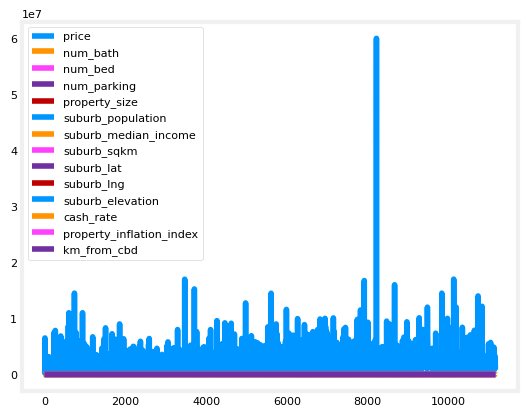

In [9]:
# plot a line graph 
data_frame.plot()

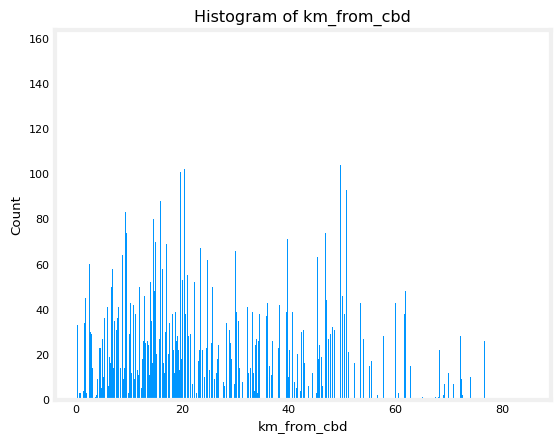

In [10]:
# Plot a histogram of a column
plt.hist(data_frame['km_from_cbd'], bins=1000)
plt.title(f"Histogram of {data_frame['km_from_cbd'].name}")
plt.ylabel('Count')
plt.xlabel(f'{data_frame["km_from_cbd"].name}')
plt.show()

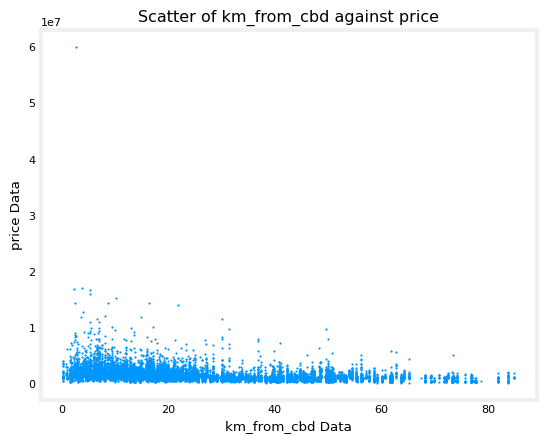

In [11]:
# Scatter plot 2 columns to see the relationship
plt.scatter(data_frame['km_from_cbd'], data_frame['price'], s=1)
plt.title(f"Scatter of {data_frame['km_from_cbd'].name} against {data_frame['price'].name}")
plt.ylabel(f"{data_frame['price'].name} Data")
plt.xlabel(f"{data_frame['km_from_cbd'].name} Data")
plt.show()

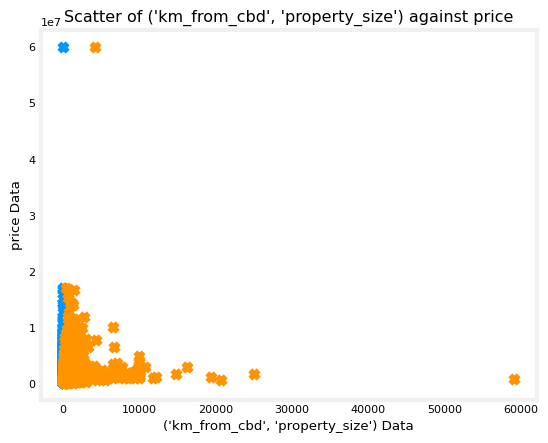

In [12]:
# Scatter plot multiples columns to see the relationship
x_plot = ['km_from_cbd', 'property_size']
for col in x_plot:
    plt.scatter(data_frame[col], data_frame['price'], marker='x')
plt.title(f"Scatter of {*x_plot,} against {data_frame['price'].name}")
plt.ylabel(f"{data_frame['price'].name} Data")
plt.xlabel(f"{*x_plot,} Data")
plt.show()

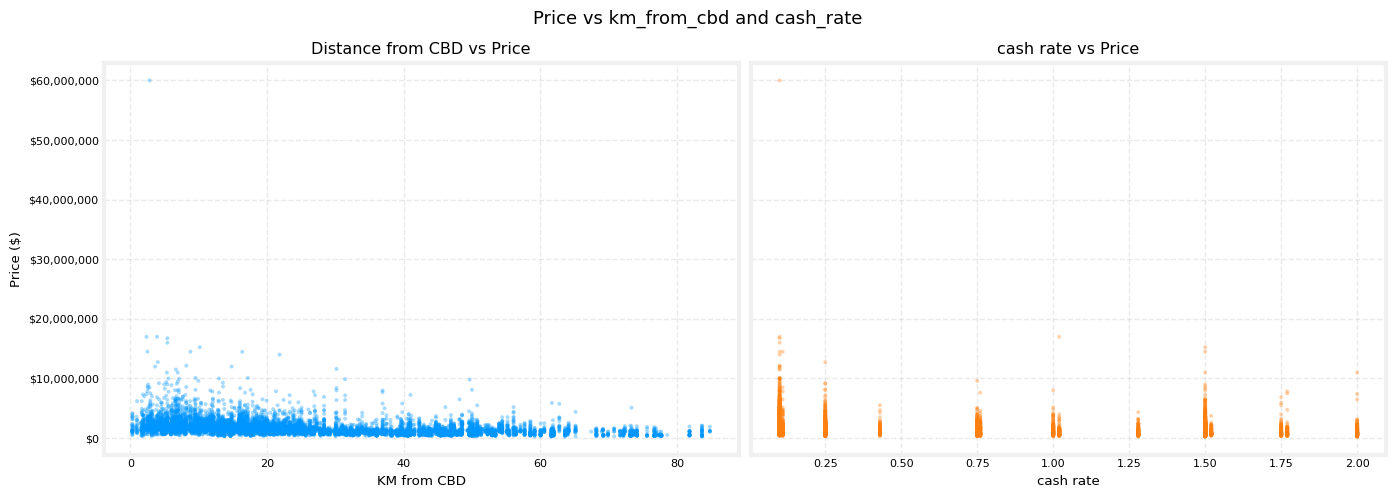

In [19]:
# # Scatter plot 2 columns in separate charts with a shared y-axis
# fig, (ax1, ax2) = plt.subplots(1,2, sharey=True)
# plt.suptitle(
#     f"Scatter of {data_frame['km_from_cbd'].name} and {data_frame['property_size'].name} against {data_frame['price'].name}"
# )
# ax1.set_ylabel(f"{data_frame['price'].name} Data")

# ax1.scatter(data_frame["km_from_cbd"], data_frame["price"])
# ax1.set_xlabel(f"{data_frame['km_from_cbd'].name} Data")

# ax2.scatter(data_frame['property_size'], data_frame['price'])
# ax2.set_xlabel(f"{data_frame['property_size'].name} Data")

# plt.show()

# Improved scatter plots: clearer labels, styling, and formatting
import matplotlib.ticker as mtick

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(14, 5))
fig.suptitle(
    f"Price vs {data_frame['km_from_cbd'].name} and {data_frame['cash_rate'].name}",
    fontsize=13,
)

# Left chart: km_from_cbd vs price
ax1.scatter(
    data_frame["km_from_cbd"], data_frame["price"], s=8, alpha=0.35, edgecolors="none"
)
ax1.set_title("Distance from CBD vs Price")
ax1.set_xlabel("KM from CBD")
ax1.set_ylabel("Price ($)")
ax1.grid(True, linestyle="--", alpha=0.4)

# Right chart: property_size vs price
ax2.scatter(
    data_frame["cash_rate"],
    data_frame["price"],
    s=8,
    alpha=0.35,
    edgecolors="none",
    color="tab:orange",
)
ax2.set_title("cash rate vs Price")
ax2.set_xlabel("cash rate")
ax2.grid(True, linestyle="--", alpha=0.4)

# Format shared y-axis as currency
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

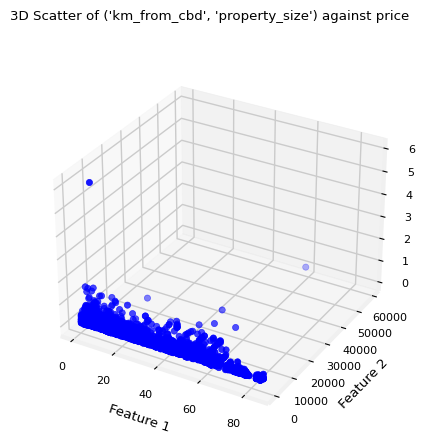

In [14]:
# 3D Scatter plot 3 columns to see the relationship

x_plot = ['km_from_cbd', 'property_size']

fig = plt.figure()
plt.suptitle(f"3D Scatter of {*x_plot,} against {data_frame['price'].name}")
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data_frame[x_plot[0]], data_frame[x_plot[1]], data_frame['price'], color='blue')

x1_range = np.linspace(data_frame[x_plot[0]].min(), data_frame[x_plot[0]].max())
x2_range = np.linspace(data_frame[x_plot[1]].min(), data_frame[x_plot[1]].max())
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)


ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Target')

plt.show()